In [11]:
%load_ext autoreload
%autoreload 2 
import numpy as np 
import shap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from Preprocess import preprocess_data
from xgboost import XGBRegressor
from xgboost.callback import EarlyStopping
from sklearn.metrics import mean_absolute_error
import optuna

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
data_orig = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols, amount_of_known = preprocess_data(filtered_time, data_orig)

0        True
1        True
2        True
3        True
4        True
        ...  
5145     True
5146     True
5147     True
5148     True
5149    False
Name: time_to_next_ev_hr, Length: 5150, dtype: bool
(4897, 3)
(4897, 8)
(5150, 8)


In [13]:
# XGBoost


#Tuning XGBoost through the Optuna library
def objective(trial):
  XGBoost = XGBRegressor(
      objective="reg:squarederror",
      n_estimators=1000,
      learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True), #sweeping 0.01 to 0.1 in the log scale for optimal learning rate
      max_depth=trial.suggest_int("max_depth",2,5), #checking max depth between 2 and 5
      subsample=trial.suggest_float("subsample",0.6,0.9), #sweeping subsample possibilites between 0.6 and 0.9
      colsample_bytree=trial.suggest_float("colsample_bytree",0.6,0.9), #sweeping bytree parameters between 0.6 and 0.9
      random_state=42
  )
  XGBoost.fit(
      X_train, y_train, eval_set=[(X_val, y_val)], verbose=False) #To see more model info set verbose=True
  predictions= XGBoost.predict(X_val)
  RMSE = root_mean_squared_error(y_val, predictions)
  return RMSE

#Finding the parameters that minimize the squared error 
optimization = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42)) # sampler ensures Optuna gives the same tuning results which gives reproducability between runs 
optimization.optimize(objective, n_trials=30) #Keeping at 30 to prevent overfitting with noise

#Showing what the parameters are
optimal_params = optimization.best_params
print("Optimal Parameters:", optimal_params)

#Running the XGBoost with the optimal parameters
XGBoost = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    **optimal_params,
    random_state=42,
)

XGBoost.fit(
    X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

#Calculating multiplicative error for XGBoost
XGBoost_Prediction = XGBoost.predict(X_test)
XGBoost_RMSE = root_mean_squared_error(y_test, XGBoost_Prediction)
XGBoost_Error = XGBoost_RMSE
print("XGBoost Error:", XGBoost_Error)

XGBoost_RMSE = mean_absolute_error(y_test, XGBoost_Prediction)
XGBoost_Error_MAE = XGBoost_RMSE
print("Mean XGBoost Error:", XGBoost_Error_MAE)

[I 2026-02-05 15:31:05,131] A new study created in memory with name: no-name-0effb122-4669-4da8-8d0f-6abc0a38d8b5
[I 2026-02-05 15:31:05,601] Trial 0 finished with value: 17875.15607378231 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 5, 'subsample': 0.8195981825434215, 'colsample_bytree': 0.779597545259111}. Best is trial 0 with value: 17875.15607378231.
[I 2026-02-05 15:31:05,829] Trial 1 finished with value: 18139.8253577755 and parameters: {'learning_rate': 0.014322493718230255, 'max_depth': 2, 'subsample': 0.6174250836504598, 'colsample_bytree': 0.8598528437324806}. Best is trial 0 with value: 17875.15607378231.
[I 2026-02-05 15:31:06,168] Trial 2 finished with value: 17966.378585678834 and parameters: {'learning_rate': 0.039913058785616795, 'max_depth': 4, 'subsample': 0.6061753482887408, 'colsample_bytree': 0.8909729556485984}. Best is trial 0 with value: 17875.15607378231.
[I 2026-02-05 15:31:06,394] Trial 3 finished with value: 18100.450796853835 and par

Optimal Parameters: {'learning_rate': 0.010256263953376912, 'max_depth': 5, 'subsample': 0.8362011524286032, 'colsample_bytree': 0.8426779498161495}
XGBoost Error: 18035.504336389127
Mean XGBoost Error: 14039.628292100695


3014    86820.0
1655    61230.0
64      48315.0
46      30780.0
1346    52335.0
         ...   
3795    84720.0
3157    42330.0
3827    47910.0
2101    43560.0
2226    88005.0
Name: time_to_next_ev_hr, Length: 900, dtype: float64
[76797.2   61768.516 59024.203 45436.918 51017.16  78087.586 68855.53
 49842.285 60368.855 51601.043 60383.094 66809.07  55912.33  52203.438
 55857.297 55576.953 54131.46  62053.383 63174.13  59358.68  77106.78
 57092.875 71610.42  59123.473 56038.184 54446.426 34986.316 54245.03
 72861.92  52849.95  72539.22  58665.258 47709.207 76734.45  66824.164
 53900.2   42360.586 48608.016 47129.156 61170.9   45667.703 51983.9
 61226.664 56366.54  49790.984 56634.75  47012.73  59361.68  56851.785
 47749.56  88905.49  77434.21  50017.383 56738.06  74552.164 56602.566
 62808.773 69186.07  58022.254 44897.4   71094.77  48726.266 74399.016
 73025.305 69641.516 51021.81  65709.32  45341.344 54843.69  53832.434
 50502.535 50366.48  74664.64  59900.043 64537.58  51025.242 6698

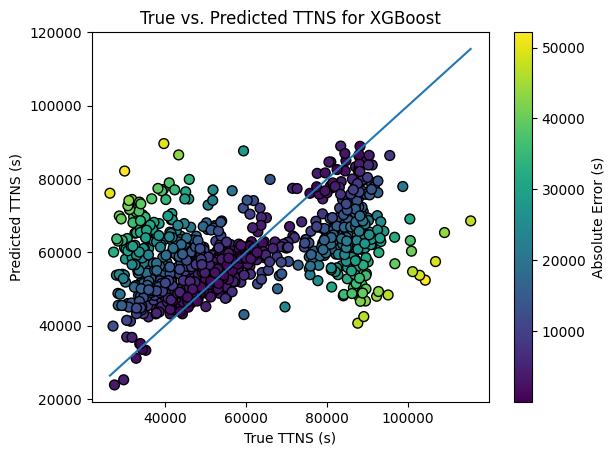

In [14]:
#XGBoost Analysis

#Taking the target column and predictions out of the log scale to calculate the average error in seconds
#y_test_secs = y_test.reshape(1,-1)
y_test_secs = y_test
XG_pred_secs = XGBoost_Prediction
print(y_test_secs)
print(XG_pred_secs)
absolute_error_secs_XG = np.abs(XG_pred_secs - y_test_secs)

#printing the true vs predicted value and error in seconds for every recrod
for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, XG_pred_secs, absolute_error_secs_XG)):
  print(f"Sample{i}: True = {true}s, Predicted = {pred}s, Error={abs_error}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, XG_pred_secs, c=absolute_error_secs_XG, cmap='viridis', s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for XGBoost")
#plt.xscale('log')
#plt.yscale('log')
plt.show()

 96%|=================== | 861/900 [00:15<00:00]       

XG Boost Drivers: tide_height    3054.577963
form_fac       2851.263818
slip_size      2408.336658
time_since     2369.807671
tide_deriv     1888.415732
high_t_evt      413.013316
dtype: float64


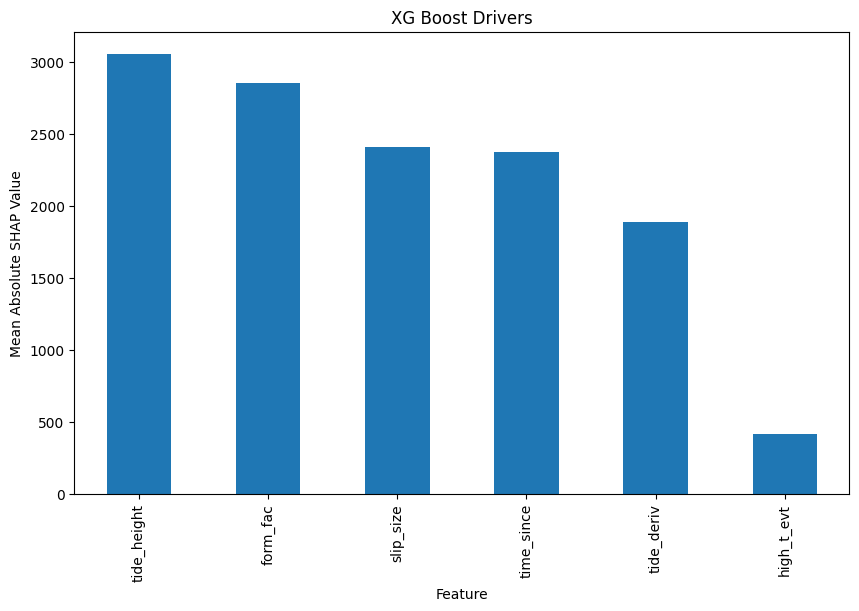

In [15]:
# Driving parameters for XG 

#Using the shap library with a copy of the training data to find the driving parameters
X_shap = X_test.copy()
X_shap = pd.DataFrame(X_shap, columns=feature_cols)
explainer_XG = shap.TreeExplainer(XGBoost, X_shap, feature_perturbation="interventional") #Using interventional to respect correlation between the features

shap_values_XG = explainer_XG.shap_values(X_shap) #Doing the tree analysis on XG using training data

XG_imp = pd.Series(np.abs(shap_values_XG).mean(axis=0), index=X_shap.columns).sort_values(ascending=False) #Analysis of driving parameters in XG

print("XG Boost Drivers:", XG_imp)

# Creating a bar graph showing the driving parameters for XGBoost 
plt.figure(figsize=(10, 6))
XG_imp.sort_values(ascending=False).plot(kind="bar")
plt.title("XG Boost Drivers")
plt.ylabel("Mean Absolute SHAP Value")
plt.xlabel("Feature")
plt.show()
